# Changing Bases Using Ordinary Differential Equations

Another natural way to define a diffeomorphism on a domain is define it through an ODE. For more information on how the transformation is done, please refer to the write-up, here we will parameterize and visualize a velocity field defined on the disk domain and see how a randomly initialized velocity field can be used for changing the basis functions.

In [1]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import math
import sys
import functools
sys.path.append('..')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)

Run the following code to visualize the velocity field captured at random timesteps on the disk domain. Note that the velocity field is tangential to the boundary by design:

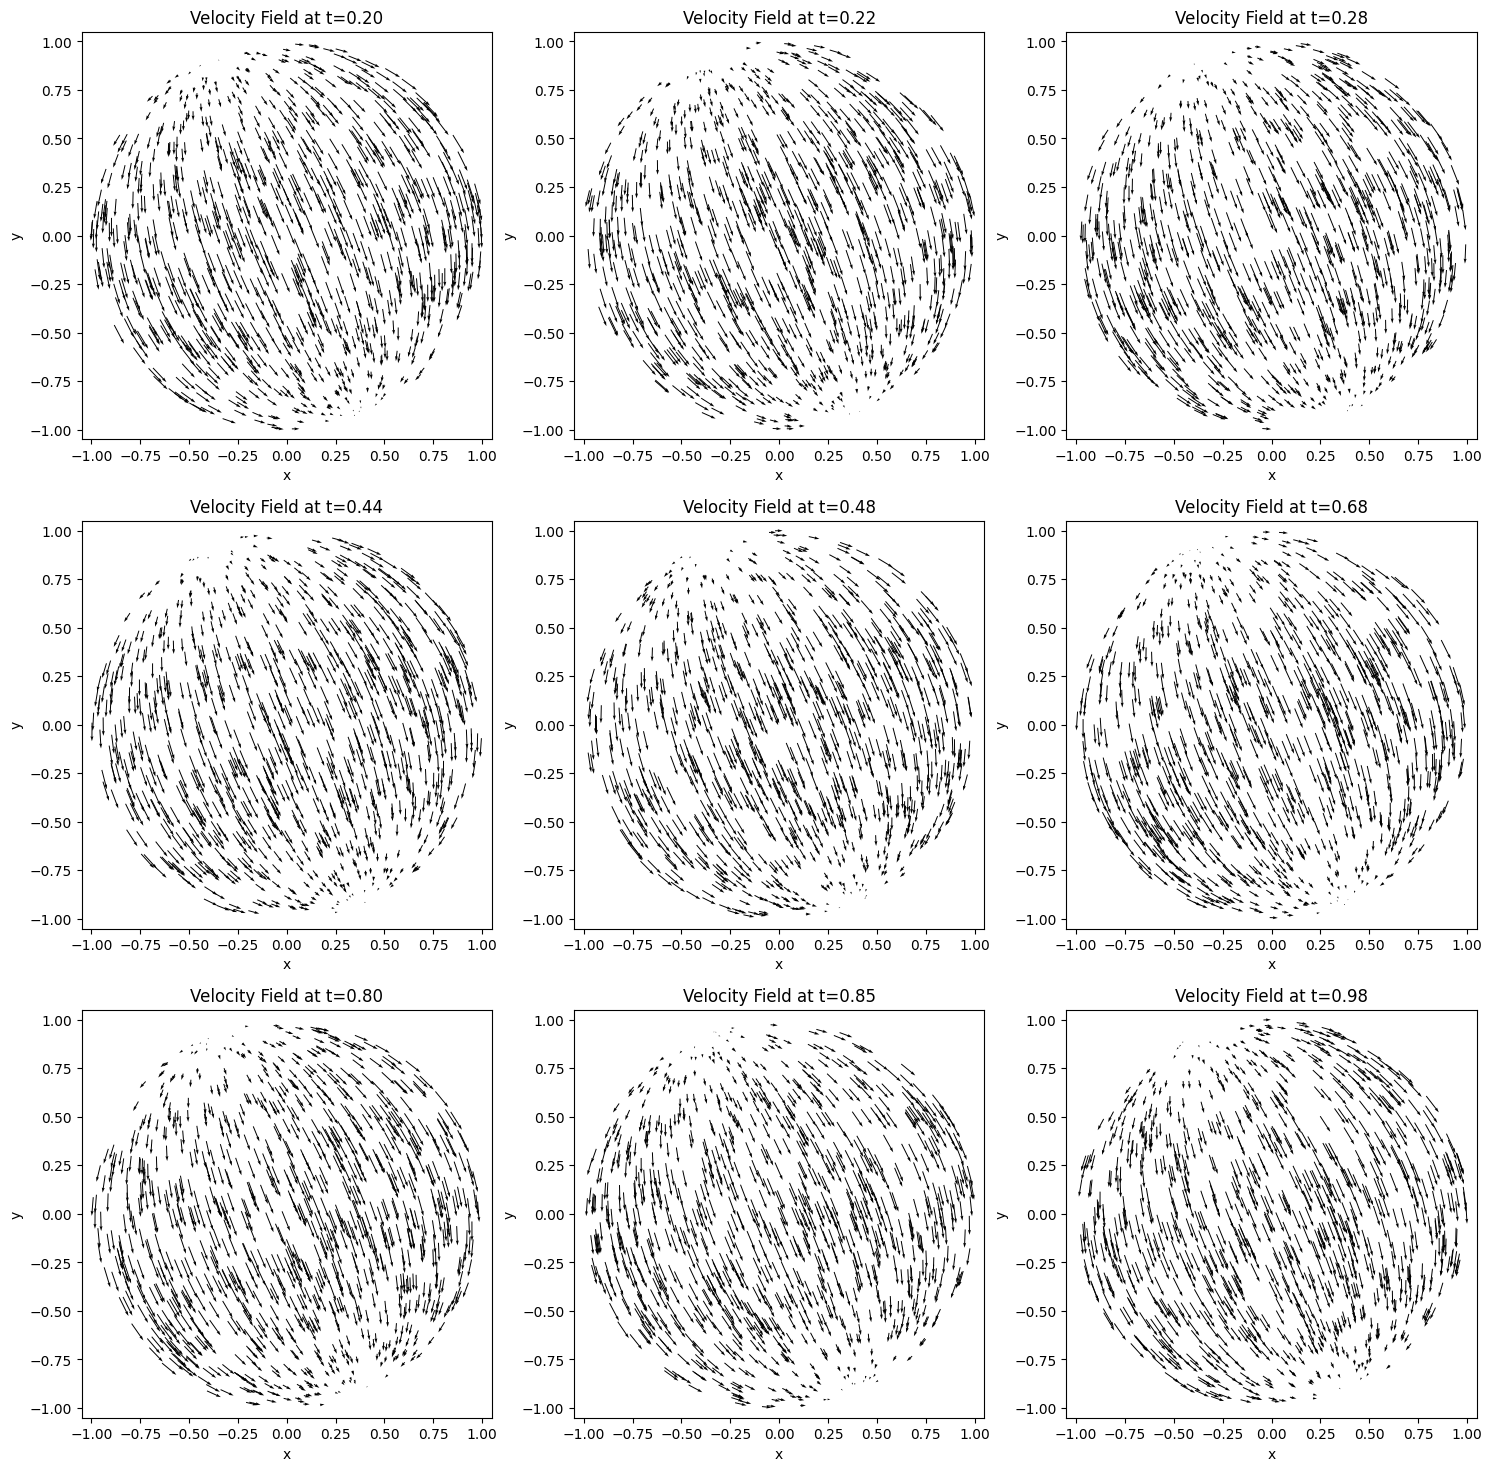

In [12]:
%autoreload 2
from basis_learning.diffeomorphisms.continuous_time import CTRadialFlow
from basis_learning.utils import sample_from_disk

torch.manual_seed(0)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,18))
N = 1000
T = CTRadialFlow(
    dimensions=2,
    gamma=1.,
    use_adjoint=True,
    method='dopri5',
    rtol=1e-6,
    atol=1e-6,
    start_time=0.,
    end_time=10.0,
).to(device)
viz_magnitude = 10.0

xy = sample_from_disk(N * 9).to(device)

# sample 9 random times in [0,1]
t = torch.rand(9).to(device)
# sort t for better visualization
t, _ = torch.sort(t)
# repeat t for each point
t = torch.repeat_interleave(t, N)
v =  viz_magnitude * T.velocity_field(t, xy)
# transform v to cartesian coordinates


for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        idx = row * 3 + col
        ax.quiver(xy[idx * N:(idx + 1) * N,0].detach().cpu(), xy[idx * N:(idx + 1) * N,1].detach().cpu(),
                  v[idx * N:(idx + 1) * N,0].detach().cpu(), v[idx * N:(idx + 1) * N,1].detach().cpu(),
                  angles='xy', scale_units='xy', scale=10.0, alpha=1)
        ax.set_title(f'Velocity Field at t={t[idx * N].item():.2f}')
        ax.set_xlim(-1.05,1.05)
        ax.set_ylim(-1.05,1.05)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()

Next, try running the ODE to deform an original tent basis:

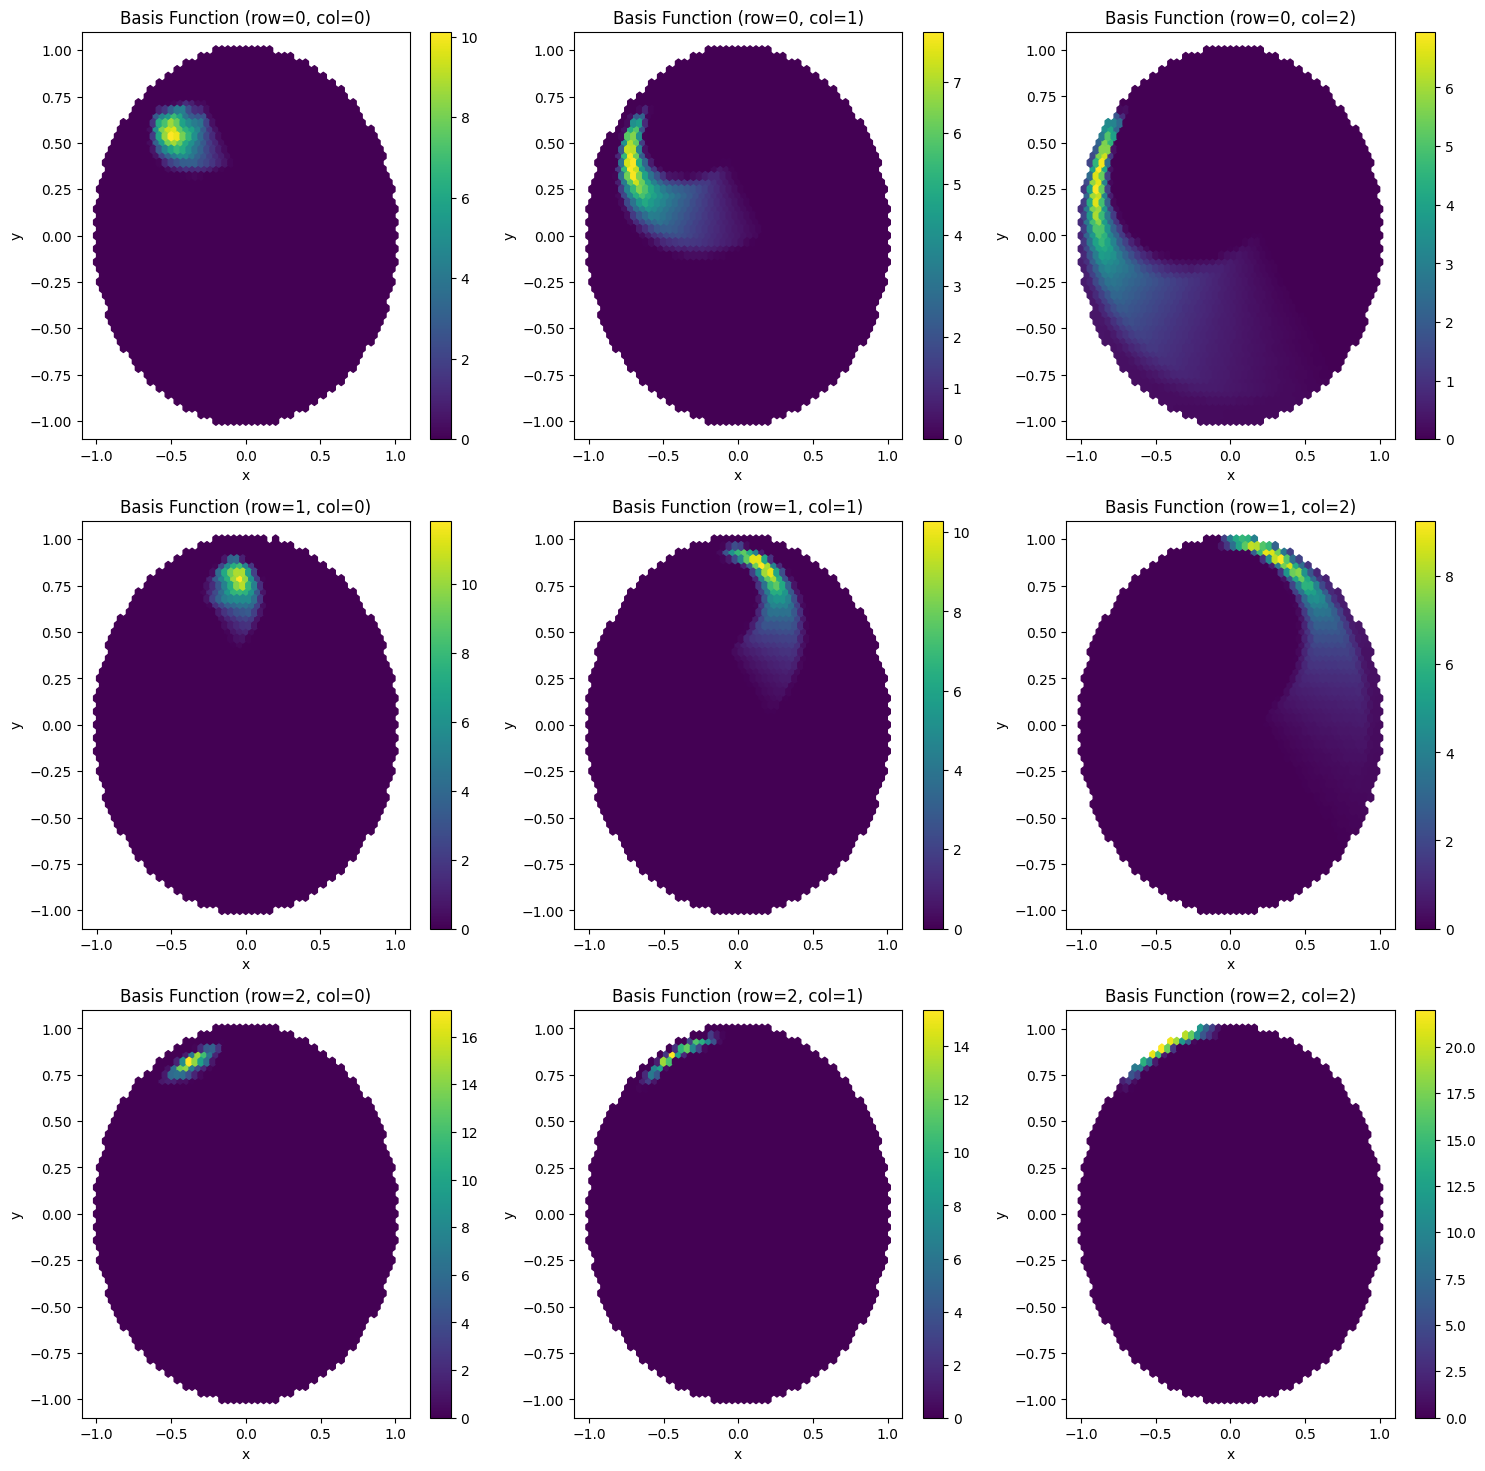

In [13]:
%autoreload 2
from basis_learning.bases import RadialTentBasis
from basis_learning.utils import deform_vals

tent_basis = RadialTentBasis(
    total_rows=3,
    total_cols=3,
    device=device,
)

# seed everything for reproducibility
torch.manual_seed(0)
N = 50000
end_time = 5.5
all_deformed_vals = []
all_vals = []
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18,18))
for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        basis_func = functools.partial(tent_basis, row=row, col=col)
        xy = tent_basis.sample_from_domain(N).to(device)
        vals = basis_func(xy).detach().cpu().numpy()
        all_vals.append(vals)
        deformed_vals = deform_vals(xy, T, basis_func)
        deformed_vals = deformed_vals.detach().cpu().numpy()
        all_deformed_vals.append(deformed_vals)
        # approximate integral by monte carlo
        ax.hexbin(xy[:,0].detach().cpu(), xy[:,1].detach().cpu(), C=deformed_vals, gridsize=50, cmap='viridis') 
        plt.colorbar(mappable=ax.collections[0], ax=ax)
        ax.set_title(f'Basis Function (row={row}, col={col})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()

Now visualize the inner products of the tent basis before and after the transformation:

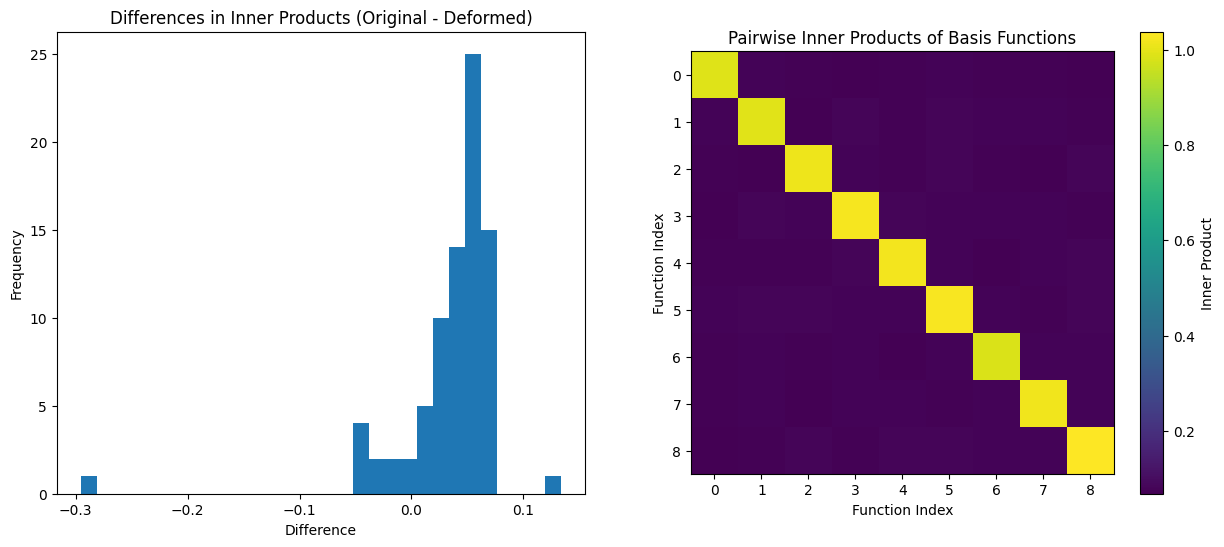

In [14]:
# compute pairwise inner products
inner_products = np.zeros((9, 9))
inner_products_deformed = np.zeros((9, 9))
fig, axes = plt.subplots(figsize=(15, 6), nrows=1, ncols=2)
for i in range(9):
    for j in range(9):
        vi = all_vals[i]
        vj = all_vals[j]
        inner_products[i, j] = (vi * vj).mean().item()
        vi_def = all_deformed_vals[i]
        vj_def = all_deformed_vals[j]
        inner_products_deformed[i, j] = (vi_def * vj_def).mean().item()
# heatmap of inner products
m = axes[1].imshow(inner_products)
# axes[1].
fig.colorbar(m, ax=axes[1], label='Inner Product')
axes[1].set_title('Pairwise Inner Products of Basis Functions')
axes[1].set_xlabel('Function Index')
axes[1].set_ylabel('Function Index')

diffs = inner_products - inner_products_deformed
axes[0].hist(diffs.flatten(), bins=30)
axes[0].set_title('Differences in Inner Products (Original - Deformed)')
axes[0].set_xlabel('Difference')
axes[0].set_ylabel('Frequency')
plt.show()
